# Reproducing Virtual Outlier Synthesis (VOS) for OOD Detection on CIFAR-10

This notebook provides a readable reimplementation of the classification-side **Virtual Outlier Synthesis (VOS)** workflow for out-of-distribution detection.

The model is trained on **CIFAR-10** as the in-distribution dataset and evaluated using **SVHN** as the out-of-distribution dataset.

## Main VOS Pipeline

1. Train a Wide ResNet classifier on CIFAR-10.
2. Store penultimate-layer features in a class-specific feature bank.
3. Estimate class-wise feature means and a shared covariance matrix.
4. Sample low-density virtual outliers from class-conditional Gaussian distributions.
5. Train an auxiliary energy-based classifier to distinguish in-distribution features from virtual outliers.
6. Evaluate the VOS-trained classifier using Maximum Softmax Probability and the standard Energy score.
7. Report AUROC, AUPR-OOD, and FPR95 for CIFAR-10 versus SVHN.

## Implementation Notes

The implementation is organized for readability and experimentation while preserving the main architecture, hyperparameters, training procedure, virtual-outlier generation process, and evaluation protocol used in the original VOS CIFAR-10 implementation.

Some utility functions, logging, checkpoint handling, and metric calculations are rewritten in a notebook-friendly format rather than copied directly from the original repository.

## Imports and Environment Setup

This section imports the libraries required for data loading, model development, training, visualization, dimensionality reduction, and out-of-distribution evaluation.

The notebook is designed to run on **Kaggle**, where PyTorch, TorchVision, NumPy, Matplotlib, and scikit-learn are typically available by default.

The imported modules are used for:

- numerical operations and reproducibility,
- configuration management,
- CIFAR-10 and SVHN data loading,
- neural-network construction and training,
- PCA-based feature visualization,
- and OOD metrics including AUROC, AUPR-OOD, and FPR95.

The `try` block checks whether scikit-learn is available before enabling PCA and metric calculations.

In [1]:
import math
import os
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms


try:
    from sklearn.decomposition import PCA
    from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print("scikit-learn is not installed. Run: pip install scikit-learn")

## Device Configuration

This section selects the available computation device for training and evaluation.

If a GPU is available in the Kaggle session, PyTorch uses CUDA. Otherwise, the notebook falls back to the CPU.

For faster training, enable a GPU accelerator in Kaggle through:

**Settings → Accelerator → GPU**

In [2]:
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)

Using device: cuda


## Experiment Configuration

This section defines the main hyperparameters used throughout training, virtual-outlier generation, evaluation, and visualization.

The configuration follows the principal settings used in the original VOS CIFAR-10 implementation:

- random seed: `1`
- training batch size: `128`
- test batch size: `200`
- Wide ResNet feature dimension: `128`
- training duration: `100` epochs
- initial learning rate: `0.1`
- SGD momentum: `0.9`
- weight decay: `5 × 10⁻⁴`
- feature-bank capacity: `1,000` features per class
- VOS activation: zero-based epoch `40`, corresponding to displayed epoch `41`
- Gaussian candidates: `10,000` per class
- selected virtual outliers: `1` per class
- covariance regularization: `1 × 10⁻⁴`
- VOS loss weight: `0.1`

The CIFAR-10 dataset is loaded from the attached Kaggle input directory. The maximum number of points used in feature visualizations is limited to `5,000` to keep plots readable and computationally manageable.

In [3]:
from dataclasses import dataclass


@dataclass
class Config:
    seed: int = 1
    data_root: str = "/kaggle/input/datasets/pankrzysiu/cifar10-python"

    batch_size: int = 128
    test_batch_size: int = 200
    num_workers: int = 4

    num_classes: int = 10
    feature_dim: int = 128

    epochs: int = 100
    learning_rate: float = 0.1
    momentum: float = 0.9
    weight_decay: float = 0.0005

    feature_bank_size: int = 1000
    start_vos_epoch: int = 40
    candidates_per_class: int = 10000
    outliers_per_class: int = 1
    covariance_eps: float = 1e-4
    vos_weight: float = 0.1
    max_visualization_points: int= 5000


cfg = Config()

print(cfg)

Config(seed=1, data_root='/kaggle/input/datasets/pankrzysiu/cifar10-python', batch_size=128, test_batch_size=200, num_workers=4, num_classes=10, feature_dim=128, epochs=100, learning_rate=0.1, momentum=0.9, weight_decay=0.0005, feature_bank_size=1000, start_vos_epoch=40, candidates_per_class=10000, outliers_per_class=1, covariance_eps=0.0001, vos_weight=0.1, max_visualization_points=5000)


## Reproducibility

This section sets the random seed for Python, NumPy, and PyTorch to make the experiment as reproducible as possible.

The same seed is applied to all available CUDA devices when GPU acceleration is enabled. This helps reduce variation in dataset shuffling, parameter initialization, and other stochastic operations.

Some small differences may still occur across hardware, CUDA versions, or non-deterministic GPU operations.

In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

## CIFAR-10 Data Preparation

This section prepares the CIFAR-10 training and test datasets using the normalization statistics and data-augmentation procedure used by the original VOS CIFAR-10 implementation.

The training pipeline applies:

- random horizontal flipping,
- random `32 × 32` cropping with four pixels of padding,
- conversion to a PyTorch tensor,
- and channel-wise normalization.

The test pipeline applies only tensor conversion and normalization so that evaluation is deterministic.

The CIFAR-10 files are loaded from the attached Kaggle dataset, so `download=False` is used. The training loader shuffles the samples at the beginning of each epoch, while the test loader preserves a fixed order.

Pinned memory is enabled automatically when CUDA is available to improve CPU-to-GPU data transfer efficiency.

In [6]:
mean = (125.3 / 255, 123.0 / 255, 113.9 / 255)
std = (63.0 / 255, 62.1 / 255, 66.7 / 255)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = datasets.CIFAR10(
    root=cfg.data_root,
    train=True,
    transform=train_transform,
    download=False,
)

test_dataset = datasets.CIFAR10(
    root=cfg.data_root,
    train=False,
    transform=test_transform,
    download=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.test_batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 50000
Test samples: 10000


## Wide ResNet Backbone

This section defines the **Wide ResNet-40-2** classifier used in the VOS experiment.

The network contains:

- residual `BasicBlock` modules,
- three groups of residual blocks,
- channel widths controlled by a widening factor of `2`,
- dropout with a rate of `0.3`,
- global average pooling,
- and a final linear classifier for the 10 CIFAR-10 classes.

The model produces a `128`-dimensional penultimate feature vector before the final classification layer.

Two forward methods are provided:

- `forward()` returns only the class logits and is used for standard classification and OOD evaluation.
- `forward_virtual()` returns both the class logits and penultimate features. The features are stored in the class-specific feature bank and later used to estimate Gaussian distributions for virtual-outlier generation.

The convolutional, batch-normalization, and linear layers are initialized following the Wide ResNet implementation used by the original VOS classification code.

In [7]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, drop_rate=0.0):
        super().__init__()

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )

        self.drop_rate = drop_rate
        self.same_channels = in_channels == out_channels

        self.shortcut = (
            None
            if self.same_channels
            else nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                bias=False,
            )
        )

    def forward(self, x):
        if self.same_channels:
            out = self.relu1(self.bn1(x))
            residual = x
        else:
            x = self.relu1(self.bn1(x))
            out = x
            residual = self.shortcut(x)

        out = self.conv1(out)
        out = self.relu2(self.bn2(out))

        if self.drop_rate > 0:
            out = F.dropout(
                out,
                p=self.drop_rate,
                training=self.training,
            )

        out = self.conv2(out)

        return residual + out


class NetworkBlock(nn.Module):
    def __init__(
        self,
        num_layers,
        in_channels,
        out_channels,
        stride,
        drop_rate,
    ):
        super().__init__()

        layers = []

        for layer_index in range(num_layers):
            layers.append(
                BasicBlock(
                    in_channels=(
                        in_channels
                        if layer_index == 0
                        else out_channels
                    ),
                    out_channels=out_channels,
                    stride=stride if layer_index == 0 else 1,
                    drop_rate=drop_rate,
                )
            )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class WideResNet(nn.Module):
    def __init__(
        self,
        depth=40,
        num_classes=10,
        widen_factor=2,
        drop_rate=0.3,
    ):
        super().__init__()

        assert (depth - 4) % 6 == 0
        num_layers_per_block = (depth - 4) // 6

        channels = [
            16,
            16 * widen_factor,
            32 * widen_factor,
            64 * widen_factor,
        ]

        self.conv1 = nn.Conv2d(
            3,
            channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )

        self.block1 = NetworkBlock(
            num_layers=num_layers_per_block,
            in_channels=channels[0],
            out_channels=channels[1],
            stride=1,
            drop_rate=drop_rate,
        )

        self.block2 = NetworkBlock(
            num_layers=num_layers_per_block,
            in_channels=channels[1],
            out_channels=channels[2],
            stride=2,
            drop_rate=drop_rate,
        )

        self.block3 = NetworkBlock(
            num_layers=num_layers_per_block,
            in_channels=channels[2],
            out_channels=channels[3],
            stride=2,
            drop_rate=drop_rate,
        )

        self.bn = nn.BatchNorm2d(channels[3])
        self.relu = nn.ReLU(inplace=True)

        self.feature_dim = channels[3]
        self.fc = nn.Linear(self.feature_dim, num_classes)

        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                n = (
                    module.kernel_size[0]
                    * module.kernel_size[1]
                    * module.out_channels
                )
                module.weight.data.normal_(
                    0,
                    math.sqrt(2.0 / n),
                )

            elif isinstance(module, nn.BatchNorm2d):
                module.weight.data.fill_(1)
                module.bias.data.zero_()

            elif isinstance(module, nn.Linear):
                module.bias.data.zero_()

    def forward_features(self, x):
        x = self.conv1(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.relu(self.bn(x))
        x = F.avg_pool2d(x, 8)

        return x.view(-1, self.feature_dim)

    def forward(self, x):
        features = self.forward_features(x)
        return self.fc(features)

    def forward_virtual(self, x):
        features = self.forward_features(x)
        logits = self.fc(features)

        return logits, features



model = WideResNet(
    depth=40,
    num_classes=cfg.num_classes,
    widen_factor=2,
    drop_rate=0.3,
).to(DEVICE)

print(model)

WideResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (block1): NetworkBlock(
    (block): Sequential(
      (0): BasicBlock(
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (shortcut): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (1): BasicBlock(
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(32, eps=

## Class-Specific Feature Bank

This section defines a class-specific feature bank for storing the penultimate-layer representations produced by the Wide ResNet.

The feature bank has the following shape:

```text
[num_classes, feature_bank_size, feature_dim]
```

For this experiment, the shape is:

```text
[10, 1000, 128]
```

This means that the bank stores up to `1,000` feature vectors for each of the `10` CIFAR-10 classes, with each feature vector containing `128` values.

During training, each feature is stored in the bank corresponding to its ground-truth class label. The features are detached from the computation graph before storage because the feature bank is used only for statistical modelling and should not retain gradients.

A circular replacement strategy is used after a class-specific bank becomes full. New features then overwrite the oldest stored features for that class.

The class provides methods to:

- update the bank with features from the current training batch,
- check whether every class-specific bank is full,
- measure the overall bank fill fraction,
- retrieve the currently valid features for a selected class.

Once the feature bank is full, its contents are used to estimate one mean feature vector per class and a shared covariance matrix. These statistics are then used to generate low-density virtual outliers.

In [8]:
class ClassFeatureBank:
    def __init__(
        self,
        num_classes: int,
        bank_size: int,
        feature_dim: int,
        device: torch.device,
    ):
        self.num_classes = num_classes
        self.bank_size = bank_size
        self.feature_dim = feature_dim
        self.device = device

        self.bank = torch.zeros(
            num_classes,
            bank_size,
            feature_dim,
            device=device,
        )

        self.counts = torch.zeros(
            num_classes,
            dtype=torch.long,
            device=device,
        )

        self.write_positions = torch.zeros(
            num_classes,
            dtype=torch.long,
            device=device,
        )

    @torch.no_grad()
    def update(self, features: torch.Tensor, labels: torch.Tensor) -> None:
        features = features.detach()

        for feature, label in zip(features, labels):
            class_id = int(label.item())
            position = int(self.write_positions[class_id].item())

            self.bank[class_id, position] = feature
            self.write_positions[class_id] = (position + 1) % self.bank_size

            if self.counts[class_id] < self.bank_size:
                self.counts[class_id] += 1

    def is_full(self) -> bool:
        return bool(torch.all(self.counts == self.bank_size).item())

    def fill_fraction(self) -> float:
        return float(self.counts.sum().item()) / (
            self.num_classes * self.bank_size
        )

    def valid_features(self, class_id: int) -> torch.Tensor:
        count = int(self.counts[class_id].item())
        return self.bank[class_id, :count]

feature_bank = ClassFeatureBank(
    num_classes=cfg.num_classes,
    bank_size=cfg.feature_bank_size,
    feature_dim=cfg.feature_dim,
    device=DEVICE,
)

print("Feature bank shape:", tuple(feature_bank.bank.shape))

Feature bank shape: (10, 1000, 128)


## Estimating Class-Conditional Gaussian Statistics

This section estimates the Gaussian statistics used to model the CIFAR-10 feature space.

The calculation is performed only after the class-specific feature bank is completely full. If any class has fewer than the required number of stored features, the function raises an error.

The function first computes one mean feature vector for each CIFAR-10 class:

```text
class_means shape: [num_classes, feature_dim]
```

For this experiment:

```text
[10, 128]
```

Each stored feature is then centred by subtracting the mean of its corresponding class.

The centred features from all classes are concatenated and used to estimate one shared covariance matrix:

```text
covariance shape: [feature_dim, feature_dim]
```

For this experiment:

```text
[128, 128]
```

A small diagonal regularization term is added to the covariance matrix:

```text
covariance_eps × I
```

with:

```text
covariance_eps = 1 × 10⁻⁴
```

This improves numerical stability and helps ensure that the covariance matrix can be used safely when constructing the multivariate Gaussian distribution.

The function returns:

- the class-wise feature means,
- and the shared covariance matrix.

These statistics are later used to sample candidate features from class-conditional Gaussian distributions and identify low-density virtual outliers.

In [9]:
@torch.no_grad()
def estimate_gaussian_statistics(
    feature_bank: ClassFeatureBank,
    covariance_eps: float = 1e-4,
) -> Tuple[torch.Tensor, torch.Tensor]:
    if not feature_bank.is_full():
        raise RuntimeError("The feature bank must be full before fitting Gaussians.")

    class_means = feature_bank.bank.mean(dim=1)

    centered_features = []
    for class_id in range(feature_bank.num_classes):
        centered = (
            feature_bank.bank[class_id]
            - class_means[class_id].unsqueeze(0)
        )
        centered_features.append(centered)

    X = torch.cat(centered_features, dim=0)

    covariance = (X.T @ X) / X.shape[0]
    covariance = covariance + covariance_eps * torch.eye(
        feature_bank.feature_dim,
        device=feature_bank.device,
    )

    return class_means, covariance

## Sampling Low-Density Virtual Outliers

This section generates synthetic out-of-distribution features from the estimated class-conditional Gaussian distributions.

For each CIFAR-10 class, a multivariate Gaussian distribution is defined using:

- the class-specific mean feature vector,
- and the shared covariance matrix.

The function then samples a large set of candidate feature vectors from each class distribution:

```text
candidates_per_class = 10,000
```

Each candidate is assigned a Gaussian log-probability. Candidates with lower log-probability lie in lower-density regions of the feature distribution and are therefore treated as more suitable virtual outliers.

The lowest-density candidates are selected using:

```text
outliers_per_class = 1
```

With 10 CIFAR-10 classes, this produces:

```text
10 virtual outliers per training batch
```

The function returns:

- the selected virtual-outlier feature vectors,
- and their corresponding Gaussian log-probabilities.

These virtual outliers are passed directly through the model's final classification layer to obtain class logits for the VOS training objective.

In [10]:
@torch.no_grad()
def sample_virtual_outliers(
    class_means: torch.Tensor,
    covariance: torch.Tensor,
    candidates_per_class: int,
    outliers_per_class: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    all_outliers = []
    all_log_probs = []

    for class_id in range(class_means.shape[0]):
        distribution = torch.distributions.MultivariateNormal(
            loc=class_means[class_id],
            covariance_matrix=covariance,
        )

        candidates = distribution.rsample(
            sample_shape=(candidates_per_class,)
        )

        log_probs = distribution.log_prob(candidates)

        # Lowest log probability = lowest-density candidate.
        selected_indices = torch.topk(
            -log_probs,
            k=outliers_per_class,
        ).indices

        all_outliers.append(candidates[selected_indices])
        all_log_probs.append(log_probs[selected_indices])

    return (
        torch.cat(all_outliers, dim=0),
        torch.cat(all_log_probs, dim=0),
    )

## Training for One Epoch

This function performs one complete training epoch for the CIFAR-10 classifier and the VOS objective.

At the beginning of the epoch, the Wide ResNet, auxiliary OOD head, and learnable energy-weighting layer are placed in training mode.

For every training batch, the function:

1. moves the images and labels to the selected device,
2. computes both class logits and penultimate-layer features,
3. updates the class-specific feature bank,
4. computes the standard CIFAR-10 classification loss,
5. activates VOS training only after the configured start epoch and once the feature bank is full,
6. generates low-density virtual outliers,
7. computes energy values for real and virtual samples,
8. trains the auxiliary OOD head,
9. combines the classification and VOS losses,
10. updates the model parameters and learning-rate scheduler.

### Standard Classification Stage

Before VOS begins, the model is trained only with cross-entropy classification loss:

```text
classification_loss = CrossEntropy(logits, labels)
```

During this stage, the feature bank is still updated so that enough class-specific features are available when VOS training starts.

### VOS Activation

VOS is enabled when both conditions are satisfied:

```text
epoch >= start_vos_epoch
```

and

```text
feature_bank.is_full() == True
```

With:

```text
start_vos_epoch = 40
```

VOS begins at zero-based epoch `40`, corresponding to displayed epoch `41`.

### Virtual-Outlier Generation

Once VOS is active, the function:

- estimates the class-wise means and shared covariance matrix,
- samples low-density virtual features,
- passes those features through the final classifier,
- and obtains virtual class logits.

### Energy-Based OOD Training

The real CIFAR-10 logits and virtual-outlier logits are converted into scalar energy values using the learnable weighted-energy function.

The auxiliary labels are defined as:

```text
ID samples          = class 1
Virtual OOD samples = class 0
```

The real and virtual energy values are concatenated and passed through the auxiliary OOD head.

The VOS loss is:

```text
vos_loss = CrossEntropy(ood_head(combined_energy), combined_labels)
```

The total training objective is:

```text
total_loss = classification_loss + vos_weight × vos_loss
```

with:

```text
vos_weight = 0.1
```

### Diagnostic Logging

For selected epochs, the function prints:

- the mean and standard deviation of ID energy,
- the mean and standard deviation of virtual-outlier energy,
- the average predicted OOD probability for ID samples,
- and the average predicted OOD probability for virtual outliers.

These values are diagnostic only and do not modify the training process.

### Returned Metrics

At the end of the epoch, the function returns:

- total loss,
- classification loss,
- VOS loss,
- classification accuracy,
- feature-bank fill fraction,
- and the number of batches in which VOS was active.

In [11]:
def train_one_epoch(
    model: nn.Module,
    ood_head: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    feature_bank: ClassFeatureBank,
    epoch: int,
    cfg: Config,
) -> Dict[str, float]:
    model.train()
    ood_head.train()
    weight_energy.train()

    total_loss_sum = 0.0
    ce_loss_sum = 0.0
    vos_loss_sum = 0.0
    correct = 0
    total = 0
    vos_batches = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, features = model.forward_virtual(images)
        feature_bank.update(features, labels)

        classification_loss = F.cross_entropy(logits, labels)
        vos_loss = torch.zeros((), device=DEVICE)

        use_vos = (
            epoch >= cfg.start_vos_epoch
            and feature_bank.is_full()
        )

        if use_vos:
            class_means, covariance = estimate_gaussian_statistics(
                feature_bank,
                covariance_eps=cfg.covariance_eps,
            )

            virtual_outliers, _ = sample_virtual_outliers(
                class_means=class_means,
                covariance=covariance,
                candidates_per_class=cfg.candidates_per_class,
                outliers_per_class=cfg.outliers_per_class,
            )

            virtual_logits = model.fc(virtual_outliers)

            id_energy = energy_score(logits)
            virtual_energy = energy_score(virtual_logits)
            if vos_batches == 0 and epoch in [40, 41, 49, 59, 79, 99]:
                with torch.no_grad():
                    id_ood_prob = torch.softmax(
                        ood_head(id_energy),
                        dim=1,
                    )[:, 0]
            
                    virtual_ood_prob = torch.softmax(
                        ood_head(virtual_energy),
                        dim=1,
                    )[:, 0]
            
                    print(
                        f"\nEpoch {epoch + 1}"
                        f"\nID energy: {id_energy.mean().item():.4f} "
                        f"± {id_energy.std().item():.4f}"
                        f"\nVirtual energy: {virtual_energy.mean().item():.4f} "
                        f"± {virtual_energy.std().item():.4f}"
                        f"\nID OOD probability: "
                        f"{id_ood_prob.mean().item():.4f}"
                        f"\nVirtual OOD probability: "
                        f"{virtual_ood_prob.mean().item():.4f}"
                    )
            
            combined_energy = torch.cat(
                [id_energy, virtual_energy],
                dim=0,
            )

            combined_labels = torch.cat([
                torch.ones(
                    id_energy.shape[0],
                    dtype=torch.long,
                    device=DEVICE,
                ),
                torch.zeros(
                    virtual_energy.shape[0],
                    dtype=torch.long,
                    device=DEVICE,
                ),
            ])

            vos_predictions = ood_head(combined_energy)
            
            vos_loss = F.cross_entropy(
                vos_predictions,
                combined_labels,
                )
            
            vos_batches += 1

        total_loss = classification_loss + cfg.vos_weight * vos_loss

        optimizer.zero_grad(set_to_none=True)
        total_loss.backward()
        optimizer.step()
        scheduler.step()

        batch_size = labels.shape[0]
        total += batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()

        total_loss_sum += total_loss.item() * batch_size
        ce_loss_sum += classification_loss.item() * batch_size
        vos_loss_sum += vos_loss.item() * batch_size

    return {
        "loss": total_loss_sum / total,
        "classification_loss": ce_loss_sum / total,
        "vos_loss": vos_loss_sum / total,
        "accuracy": correct / total,
        "feature_bank_fill": feature_bank.fill_fraction(),
        "vos_batches": float(vos_batches),
    }

## Classifier Evaluation

This function evaluates the trained Wide ResNet on a labelled dataset without updating any model parameters.

The `@torch.no_grad()` decorator disables gradient computation, which reduces memory usage and speeds up evaluation.

The model is first switched to evaluation mode:

```text
model.eval()
```

This ensures that layers such as batch normalization and dropout behave correctly during testing.

For each batch, the function:

1. moves the images and labels to the selected device,
2. computes the class logits,
3. calculates the cross-entropy loss,
4. selects the class with the highest logit as the prediction,
5. counts the number of correct predictions,
6. accumulates the total loss and number of samples.

The final classification loss is averaged over all samples:

```text
average loss = total loss / number of samples
```

The classification accuracy is calculated as:

```text
accuracy = correct predictions / total samples
```

The function returns:

- average classification loss,
- classification accuracy.

This evaluation is used during training to monitor CIFAR-10 test performance after each epoch.

In [12]:
@torch.no_grad()
def evaluate_classifier(
    model: nn.Module,
    loader: DataLoader,
) -> Dict[str, float]:
    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)

        loss = F.cross_entropy(
            logits,
            labels,
        )

        batch_size = labels.shape[0]
        total += batch_size

        correct += (
            logits.argmax(dim=1) == labels
        ).sum().item()

        loss_sum += loss.item() * batch_size

    return {
        "loss": loss_sum / total,
        "accuracy": correct / total,
    }

## Energy-Based OOD Head, Optimizer, and Learning-Rate Scheduler

This section defines the learnable components used for the VOS objective and configures the optimization procedure.

### Learnable Weighted Energy

The `weight_energy` layer maps the 10 class logits to a single scalar value:

```text
10 class logits → 1 weighted energy value
```

Its weights are initialized from a uniform distribution.

During VOS training, this layer learns how strongly each class logit should contribute to the energy representation used by the auxiliary OOD classifier.

### Auxiliary OOD Head

The `EnergyOODHead` receives one scalar energy value per sample and predicts two classes:

```text
class 0 = virtual OOD
class 1 = in-distribution
```

The energy tensor is reshaped to:

```text
[batch_size, 1]
```

before being passed through the final linear classifier.

This head is used only during VOS training and related diagnostics. The final CIFAR-10 versus SVHN evaluation uses the standard MSP and unweighted Energy scores computed directly from the model logits.

### Optimizer

Stochastic Gradient Descent is used to jointly optimize:

- the Wide ResNet classifier,
- the learnable weighted-energy layer,
- and the auxiliary OOD head.

The optimizer uses:

```text
learning rate = 0.1
momentum = 0.9
weight decay = 5 × 10⁻⁴
Nesterov momentum = enabled
```

### Cosine-Annealing Learning Rate

A cosine-annealing schedule gradually decreases the learning rate over all training iterations.

The schedule is updated after every training batch rather than once per epoch.

The learning-rate multiplier begins near `1.0` and smoothly decreases toward:

```text
1 × 10⁻⁶ / initial learning rate
```

This gives a final absolute learning rate close to:

```text
1 × 10⁻⁶
```

The total number of scheduler steps is:

```text
number of epochs × number of training batches per epoch
```

In [13]:
weight_energy = nn.Linear(
    cfg.num_classes,
    1,
).to(DEVICE)

nn.init.uniform_(weight_energy.weight)





class EnergyOODHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Linear(1, 2)

    def forward(self, energy: torch.Tensor) -> torch.Tensor:
        return self.classifier(energy.view(-1, 1))


ood_head = EnergyOODHead().to(DEVICE)


optimizer = torch.optim.SGD(
    list(model.parameters())
    + list(weight_energy.parameters())
    + list(ood_head.parameters()),
    lr=cfg.learning_rate,
    momentum=cfg.momentum,
    weight_decay=cfg.weight_decay,
    nesterov=True,
)

def cosine_annealing(
    step: int,
    total_steps: int,
    lr_max: float,
    lr_min: float,
) -> float:
    return lr_min + (lr_max - lr_min) * 0.5 * (
        1.0 + np.cos(step / total_steps * np.pi)
    )


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: cosine_annealing(
        step=step,
        total_steps=cfg.epochs * len(train_loader),
        lr_max=1.0,
        lr_min=1e-6 / cfg.learning_rate,
    ),
)

## Learnable Weighted-Energy Score

This function converts the model's 10 class logits into a single scalar energy value for each sample.

Unlike the standard Energy score used during final OOD evaluation, this training-time energy function contains learnable class-specific weights.

### Numerical Stability

The maximum logit is first subtracted before exponentiation:

```text
shifted_logits = logits - maximum_logit
```

This prevents very large exponential values and improves numerical stability.

The maximum logit is added back after the weighted log-sum-exp calculation.

### Positive Class Weights

The weights from `weight_energy` are passed through a ReLU operation:

```text
positive_weights = ReLU(weight_energy.weight)
```

This constrains the effective class weights to be non-negative.

Each exponentiated class logit is multiplied by its corresponding learnable weight:

```text
weighted_exponentials
    = positive_weights × exp(shifted_logits)
```

The resulting weighted-energy value is:

```text
weighted energy
    = maximum logit
    + log(sum(weighted exponentials))
```

The function returns one scalar energy value per input sample.

### Role in VOS Training

This weighted energy is used only for the auxiliary VOS training objective:

```text
class logits
→ learnable weighted energy
→ auxiliary OOD head
→ ID or virtual-OOD prediction
```

The auxiliary labels are:

```text
class 0 = virtual OOD
class 1 = in-distribution
```

The final CIFAR-10 versus SVHN evaluation does not use this learnable weighted-energy function. It uses the standard unweighted Energy score:

```text
Energy(x) = -logsumexp(logits)
```

In [14]:
def energy_score(logits: torch.Tensor) -> torch.Tensor:
    maximum = torch.max(
        logits,
        dim=1,
        keepdim=True,
    ).values

    shifted_logits = logits - maximum

    positive_weights = F.relu(
        weight_energy.weight
    )

    weighted_exponentials = (
        positive_weights
        * torch.exp(shifted_logits)
    )

    return (
        maximum.squeeze(1)
        + torch.log(
            weighted_exponentials.sum(dim=1)
        )
    )

## Full Training Loop

This section trains the Wide ResNet for the configured number of epochs and evaluates the classifier on the CIFAR-10 test set after every epoch.

For each epoch, the notebook:

1. runs one complete training epoch,
2. updates the feature bank,
3. applies the VOS objective when its activation conditions are satisfied,
4. evaluates the classifier on the CIFAR-10 test set,
5. stores the training and evaluation metrics,
6. prints a compact progress summary.

The recorded training metrics include:

- total training loss,
- classification cross-entropy loss,
- VOS loss,
- training accuracy,
- feature-bank fill percentage,
- number of batches using the VOS objective.

The recorded test metrics include:

- CIFAR-10 test loss,
- CIFAR-10 test accuracy.

The feature bank is expected to reach:

```text
100.0%
```

before VOS training begins.

With:

```text
start_vos_epoch = 40
```

the first 40 displayed epochs use classification loss only. VOS becomes active from displayed epoch 41, provided that the feature bank is full.

The metrics from every epoch are stored in the `history` list for later visualization and analysis.

In [15]:
history: List[Dict[str, float]] = []

for epoch in range(cfg.epochs):
    train_metrics = train_one_epoch(
        model=model,
        ood_head=ood_head,
        loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        feature_bank=feature_bank,
        epoch=epoch,
        cfg=cfg,
    )

    test_metrics = evaluate_classifier(
        model=model,
        loader=test_loader,
    )

    row = {
        "epoch": epoch + 1,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }
    history.append(row)

    print(
        f"Epoch {epoch + 1:02d}/{cfg.epochs} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"CE {train_metrics['classification_loss']:.4f} | "
        f"VOS {train_metrics['vos_loss']:.4f} | "
        f"train acc {train_metrics['accuracy']:.3f} | "
        f"test acc {test_metrics['accuracy']:.3f} | "
        f"bank {train_metrics['feature_bank_fill']:.1%} | "
        f"VOS batches {int(train_metrics['vos_batches'])}"
    )

Epoch 01/100 | train loss 1.5938 | CE 1.5938 | VOS 0.0000 | train acc 0.405 | test acc 0.429 | bank 100.0% | VOS batches 0
Epoch 02/100 | train loss 1.0915 | CE 1.0915 | VOS 0.0000 | train acc 0.608 | test acc 0.628 | bank 100.0% | VOS batches 0
Epoch 03/100 | train loss 0.9058 | CE 0.9058 | VOS 0.0000 | train acc 0.679 | test acc 0.663 | bank 100.0% | VOS batches 0
Epoch 04/100 | train loss 0.7803 | CE 0.7803 | VOS 0.0000 | train acc 0.726 | test acc 0.680 | bank 100.0% | VOS batches 0
Epoch 05/100 | train loss 0.7000 | CE 0.7000 | VOS 0.0000 | train acc 0.760 | test acc 0.752 | bank 100.0% | VOS batches 0
Epoch 06/100 | train loss 0.6479 | CE 0.6479 | VOS 0.0000 | train acc 0.777 | test acc 0.773 | bank 100.0% | VOS batches 0
Epoch 07/100 | train loss 0.6095 | CE 0.6095 | VOS 0.0000 | train acc 0.791 | test acc 0.732 | bank 100.0% | VOS batches 0
Epoch 08/100 | train loss 0.5831 | CE 0.5831 | VOS 0.0000 | train acc 0.798 | test acc 0.784 | bank 100.0% | VOS batches 0
Epoch 09/100 | t

## Virtual-Outlier OOD Head Diagnostic

This section evaluates how the trained auxiliary OOD head responds to newly sampled virtual outliers.

The Wide ResNet, weighted-energy layer, and auxiliary OOD head are first switched to evaluation mode. Gradient computation is disabled because this step is only used for inspection and does not update any parameters.

The diagnostic performs the following steps:

1. estimate the class-wise feature means and shared covariance matrix from the completed feature bank,
2. sample a new set of low-density virtual outliers,
3. pass the virtual features through the model's final classification layer,
4. compute the same learnable weighted-energy score used during VOS training,
5. pass the energy values through the auxiliary OOD head,
6. calculate the average predicted probability for each auxiliary class.

The auxiliary class definitions are:

```text
class 0 = virtual OOD
class 1 = in-distribution
```

Therefore, the expected behaviour is:

```text
Virtual OOD class-0 mean → high
Virtual OOD class-1 mean → low
```

This cell is a post-training diagnostic only. It does not affect the trained model or the final CIFAR-10 versus SVHN evaluation.

In [16]:
model.eval()
ood_head.eval()
weight_energy.eval()

with torch.no_grad():
    class_means, covariance = estimate_gaussian_statistics(
        feature_bank,
        cfg.covariance_eps,
    )

    virtual_outliers, _ = sample_virtual_outliers(
        class_means,
        covariance,
        candidates_per_class=cfg.candidates_per_class,
        outliers_per_class=cfg.outliers_per_class,
    )

    virtual_class_logits = model.fc(virtual_outliers)

    # Use the same weighted energy used during VOS training
    virtual_energy = energy_score(
        virtual_class_logits
    )

    virtual_probs = torch.softmax(
        ood_head(virtual_energy),
        dim=1,
    )

print(
    "Virtual OOD class-0 mean:",
    virtual_probs[:, 0].mean().item(),
)

print(
    "Virtual OOD class-1 mean:",
    virtual_probs[:, 1].mean().item(),
)

Virtual OOD class-0 mean: 0.07758602499961853
Virtual OOD class-1 mean: 0.9224140048027039


## Virtual-Outlier Output Shape Check

This section verifies the output structure returned by the virtual-outlier sampling function.

The function returns a tuple containing:

1. the selected virtual-outlier feature vectors,
2. the Gaussian log-probabilities of those selected outliers.

With:

```text
num_classes = 10
outliers_per_class = 1
feature_dim = 128
```

the expected output shapes are:

```text
virtual_outliers: [10, 128]
log_probabilities: [10]
```

The first printed value confirms that the function returns a tuple.

The second printed value confirms the shape of each returned tensor.

This is a diagnostic check only and does not affect training or evaluation.

In [17]:
result = sample_virtual_outliers(
    class_means,
    covariance,
    candidates_per_class=cfg.candidates_per_class,
    outliers_per_class=cfg.outliers_per_class,
)

print(type(result))
print([x.shape if torch.is_tensor(x) else type(x) for x in result])

<class 'tuple'>
[torch.Size([10, 128]), torch.Size([10])]


## ID and Virtual-Outlier Energy Comparison

This section compares the learnable weighted-energy values of real CIFAR-10 samples and newly generated virtual outliers.

The model is first switched to evaluation mode, and one batch of CIFAR-10 training images is selected.

The diagnostic then:

1. computes class logits for the real CIFAR-10 images,
2. estimates the class-wise feature means and shared covariance matrix,
3. generates a new set of low-density virtual outliers,
4. passes the virtual features through the final classification layer,
5. calculates the same weighted-energy score used during VOS training for both groups,
6. reports the mean energy for real and virtual samples.

The two printed values are:

```text
ID energy mean
Virtual energy mean
```

The goal is to check whether the learned weighted-energy representation separates real in-distribution samples from virtual outliers.

The exact ordering of the two means depends on how the auxiliary OOD head learns to map energy values to its two output classes. Therefore, this comparison should be interpreted together with the auxiliary OOD probabilities:

```text
ID samples          → low predicted probability for class 0
Virtual outliers    → high predicted probability for class 0
```

This cell is a post-training diagnostic only. It does not modify the model and does not affect the final CIFAR-10 versus SVHN evaluation.

In [18]:
model.eval()

images, labels = next(iter(train_loader))
images = images.to(DEVICE)

with torch.no_grad():
    logits = model(images)

    class_means, covariance = estimate_gaussian_statistics(
        feature_bank,
        cfg.covariance_eps,
    )

    virtual_outliers, _ = sample_virtual_outliers(
        class_means,
        covariance,
        candidates_per_class=cfg.candidates_per_class,
        outliers_per_class=cfg.outliers_per_class,
    )

    virtual_logits = model.fc(virtual_outliers)

    id_energy = energy_score(logits)
    virtual_energy = energy_score(virtual_logits)

print("ID energy mean:", id_energy.mean().item())
print("Virtual energy mean:", virtual_energy.mean().item())

ID energy mean: 5.069378852844238
Virtual energy mean: 4.654627799987793


## Training Curves

This section visualizes the main training metrics recorded across all epochs.

The first plot shows:

- total training loss,
- classification cross-entropy loss,
- VOS loss.

Before VOS is activated, the VOS loss remains zero. Once VOS begins, the total loss combines the classification and weighted VOS objectives:

```text
total loss = classification loss + 0.1 × VOS loss
```

The second plot shows the training classification accuracy across epochs.

These curves help inspect:

- whether the classifier is learning normally,
- when the VOS objective becomes active,
- whether the losses remain stable,
- and how classification accuracy changes during training.

The metrics are read from the `history` list collected during the full training loop.

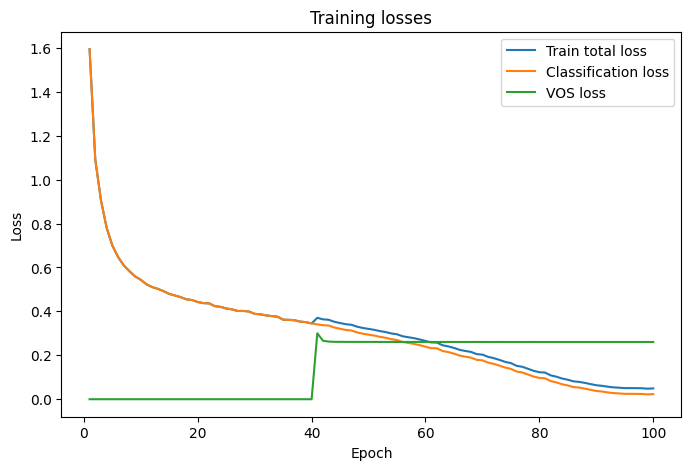

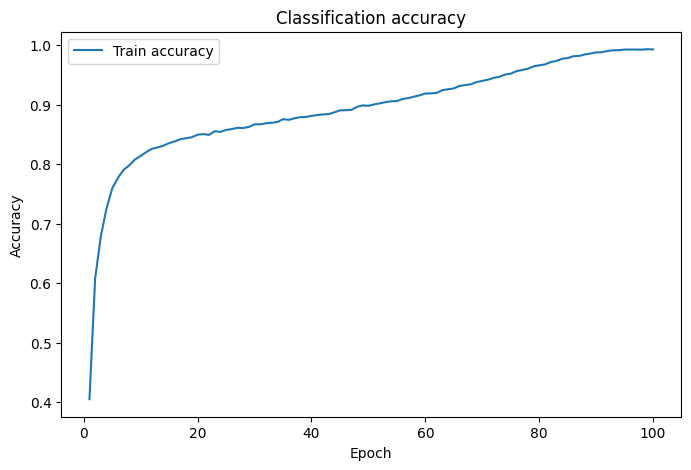

In [20]:
epochs = [row["epoch"] for row in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, [row["train_loss"] for row in history], label="Train total loss")
plt.plot(epochs, [row["train_classification_loss"] for row in history], label="Classification loss")
plt.plot(epochs, [row["train_vos_loss"] for row in history], label="VOS loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training losses")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, [row["train_accuracy"] for row in history], label="Train accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classification accuracy")
plt.legend()
plt.show()

## Gaussian Statistics and Virtual-Outlier Summary

This section checks whether the class-specific feature bank is full before estimating the Gaussian feature distribution.

If the feature bank is not yet full, the notebook prints a warning and skips virtual-outlier generation.

Once the bank is full, the section:

1. estimates the class-wise feature means,
2. estimates the shared covariance matrix,
3. samples low-density virtual outliers,
4. reports the shape of each result,
5. prints the range of Gaussian log-probabilities assigned to the selected outliers.

The expected shapes are:

```text
Class means: [10, 128]
Shared covariance: [128, 128]
Virtual outliers: [10, 128]
```

The selected log-probability range indicates how unlikely the chosen virtual features are under their corresponding class-conditional Gaussian distributions.

Lower log-probability values correspond to lower-density regions and therefore more extreme virtual outliers.

This cell is a post-training inspection step and does not update the model.

In [21]:
if not feature_bank.is_full():
    print(
        "The feature bank is not full yet. Train for more epochs or reduce "
        "cfg.feature_bank_size."
    )
else:
    class_means, shared_covariance = estimate_gaussian_statistics(
        feature_bank,
        covariance_eps=cfg.covariance_eps,
    )

    virtual_outliers, selected_log_probs = sample_virtual_outliers(
        class_means=class_means,
        covariance=shared_covariance,
        candidates_per_class=cfg.candidates_per_class,
        outliers_per_class=cfg.outliers_per_class,
    )

    print("Class means:", tuple(class_means.shape))
    print("Shared covariance:", tuple(shared_covariance.shape))
    print("Virtual outliers:", tuple(virtual_outliers.shape))
    print("Selected log-probability range:")
    print(
        float(selected_log_probs.min().item()),
        "to",
        float(selected_log_probs.max().item()),
    )

Class means: (10, 128)
Shared covariance: (128, 128)
Virtual outliers: (10, 128)
Selected log-probability range:
232.4922637939453 to 242.8015594482422


## PCA Visualization of ID Features and Virtual Outliers

This section projects the high-dimensional feature space into two dimensions using Principal Component Analysis (PCA).

The visualization is generated only when:

- scikit-learn is available,
- and the class-specific feature bank is full.

The plot includes:

- stored CIFAR-10 feature vectors,
- class-wise feature means,
- sampled virtual outliers.

Because the complete feature bank contains:

```text
10 classes × 1,000 features = 10,000 feature vectors
```

the number of real features used in the plot is limited to:

```text
max_visualization_points = 5,000
```

A fixed random seed is used when selecting this subset so that the visualization is reproducible.

The real features, class means, and virtual outliers are concatenated before fitting PCA. This ensures that all three groups are projected into the same two-dimensional coordinate system.

In the resulting plot:

- small points represent stored CIFAR-10 features,
- `X` markers represent class means,
- star markers represent virtual outliers.

The visualization provides an approximate view of how the virtual outliers relate to the learned in-distribution feature clusters.

Because PCA preserves only the directions with the largest variance, the two-dimensional plot is useful for qualitative inspection but does not fully represent the original 128-dimensional feature space.

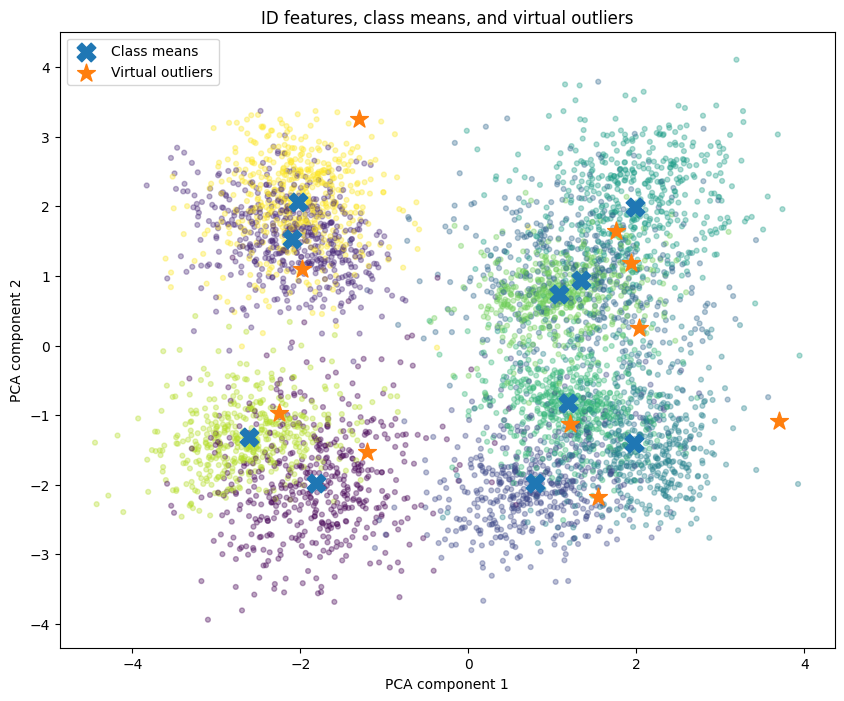

In [22]:
if not SKLEARN_AVAILABLE:
    print("Install scikit-learn to run PCA: pip install scikit-learn")
elif not feature_bank.is_full():
    print("Train until the feature bank is full.")
else:
    real_features = feature_bank.bank.reshape(
        -1,
        cfg.feature_dim,
    ).detach().cpu().numpy()

    real_labels = np.repeat(
        np.arange(cfg.num_classes),
        cfg.feature_bank_size,
    )

    means_np = class_means.detach().cpu().numpy()
    outliers_np = virtual_outliers.detach().cpu().numpy()

    if len(real_features) > cfg.max_visualization_points:
        rng = np.random.default_rng(cfg.seed)
        indices = rng.choice(
            len(real_features),
            size=cfg.max_visualization_points,
            replace=False,
        )
        real_features_plot = real_features[indices]
        real_labels_plot = real_labels[indices]
    else:
        real_features_plot = real_features
        real_labels_plot = real_labels

    combined = np.concatenate([
        real_features_plot,
        means_np,
        outliers_np,
    ])

    projection = PCA(n_components=2, random_state=cfg.seed).fit_transform(combined)

    n_real = len(real_features_plot)
    n_means = len(means_np)

    real_2d = projection[:n_real]
    means_2d = projection[n_real:n_real + n_means]
    outliers_2d = projection[n_real + n_means:]

    plt.figure(figsize=(10, 8))

    scatter = plt.scatter(
        real_2d[:, 0],
        real_2d[:, 1],
        c=real_labels_plot,
        alpha=0.35,
        s=12,
    )

    plt.scatter(
        means_2d[:, 0],
        means_2d[:, 1],
        marker="X",
        s=180,
        label="Class means",
    )

    plt.scatter(
        outliers_2d[:, 0],
        outliers_2d[:, 1],
        marker="*",
        s=180,
        label="Virtual outliers",
    )

    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.title("ID features, class means, and virtual outliers")
    plt.legend()
    plt.show()

## Collecting OOD Scores

This function collects out-of-distribution scores from a model over a given dataset.

The model is switched to evaluation mode, and gradient computation is disabled to reduce memory usage and speed up inference.

For each batch, the function:

1. moves the images to the selected device,
2. computes the model logits,
3. converts the logits into softmax probabilities,
4. calculates the Maximum Softmax Probability score,
5. calculates the standard unweighted Energy score,
6. stores the scores on the CPU.

### Maximum Softmax Probability

The MSP-based OOD score is defined as:

```text
MSP OOD score = 1 - maximum softmax probability
```

A higher value indicates that the model is less confident and the sample is more likely to be out-of-distribution.

### Energy Score

The standard Energy score is defined as:

```text
Energy = -logsumexp(logits)
```

With this sign convention, higher values indicate more OOD-like samples.

This is the unweighted Energy score used during final evaluation. It is different from the learnable weighted-energy function used inside the VOS training objective.

### Limiting the Number of Samples

The optional `max_examples` argument limits how many samples are collected from the loader.

This is used to evaluate exactly 2,000 SVHN images while keeping all CIFAR-10 test samples.

If the final batch would exceed the requested limit, the batch is sliced so that the returned score arrays contain exactly the requested number of examples.

The function returns two NumPy arrays:

```text
MSP
Energy
```

Each array contains one OOD score per evaluated image.

In [23]:
@torch.no_grad()
def collect_ood_scores(
    model: nn.Module,
    loader: DataLoader,
    max_examples: int | None = None,
) -> Dict[str, np.ndarray]:
    model.eval()

    msp_scores = []
    energy_scores = []
    collected = 0

    for images, _ in loader:
        if max_examples is not None:
            remaining = max_examples - collected

            if remaining <= 0:
                break

            # Handles cases where the final batch would exceed max_examples
            images = images[:remaining]

        images = images.to(DEVICE)

        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)

        # Higher score means more OOD-like
        msp = 1.0 - probabilities.max(dim=1).values

        # Original repo-style unweighted energy
        energy = -torch.logsumexp(
            logits,
            dim=1,
        )

        msp_scores.append(msp.cpu())
        energy_scores.append(energy.cpu())

        collected += images.size(0)

    return {
        "MSP": torch.cat(msp_scores).numpy(),
        "Energy": torch.cat(energy_scores).numpy(),
    }

## OOD Evaluation Metrics

This section calculates the main metrics used to evaluate out-of-distribution detection performance.

The evaluation compares:

- CIFAR-10 test samples as in-distribution data,
- SVHN samples as out-of-distribution data.

The labels are assigned as:

```text
CIFAR-10 = 0
SVHN     = 1
```

Because the collected MSP and Energy scores are defined so that higher values indicate more OOD-like samples, the metrics can be calculated directly from these labels and scores.

### AUROC

The Area Under the Receiver Operating Characteristic Curve measures how well the score ranks OOD samples above ID samples across all possible thresholds.

```text
Higher AUROC is better.
```

An AUROC of `1.0` indicates perfect separation, while `0.5` corresponds to random ranking.

### AUPR-OOD

The Area Under the Precision-Recall Curve treats OOD samples as the positive class.

```text
Higher AUPR-OOD is better.
```

This metric is useful for measuring how accurately the method identifies OOD samples while controlling false detections.

### FPR95

FPR95 is the false-positive rate when the true-positive rate for OOD samples reaches at least `95%`.

The helper function first computes the ROC curve and selects the first threshold where:

```text
TPR ≥ 0.95
```

It then returns the corresponding false-positive rate.

```text
Lower FPR95 is better.
```

A lower value means that fewer CIFAR-10 samples are incorrectly classified as OOD while detecting at least 95% of the SVHN samples.

The evaluation function calculates AUROC, AUPR-OOD, and FPR95 separately for each scoring method, including MSP and Energy.

In [24]:
def fpr_at_95_tpr(
    labels: np.ndarray,
    scores: np.ndarray,
) -> float:
    fpr, tpr, _ = roc_curve(labels, scores)

    valid = np.where(tpr >= 0.95)[0]
    if len(valid) == 0:
        return 1.0

    return float(fpr[valid[0]])


def evaluate_ood_scores(
    id_scores: Dict[str, np.ndarray],
    ood_scores: Dict[str, np.ndarray],
) -> Dict[str, Dict[str, float]]:
    if not SKLEARN_AVAILABLE:
        raise RuntimeError("Install scikit-learn to calculate OOD metrics.")

    results = {}

    for method in id_scores:
        scores = np.concatenate([
            id_scores[method],
            ood_scores[method],
        ])

        labels = np.concatenate([
            np.zeros(len(id_scores[method]), dtype=np.int64),
            np.ones(len(ood_scores[method]), dtype=np.int64),
        ])

        results[method] = {
            "AUROC": float(roc_auc_score(labels, scores)),
            "AUPR-OOD": float(average_precision_score(labels, scores)),
            "FPR95": fpr_at_95_tpr(labels, scores),
        }

    return results

## CIFAR-10 vs SVHN OOD Evaluation

This section evaluates the trained VOS model using CIFAR-10 as the in-distribution dataset and SVHN as the out-of-distribution dataset.

### SVHN Dataset Setup

The official cropped SVHN test split is loaded through TorchVision:

```text
test_32x32.mat
```

Because Kaggle input directories are read-only, the dataset is downloaded into:

```text
/kaggle/working/svhn
```

The Kaggle Internet option must be enabled when the dataset is downloaded for the first time.

The SVHN loader uses:

```text
batch size = 200
shuffle = True
```

Shuffling allows a random subset of SVHN samples to be selected during evaluation.

### OOD Score Collection

The evaluation uses:

```text
10,000 CIFAR-10 test images
2,000 SVHN test images
```

All CIFAR-10 test samples are used as in-distribution data.

For SVHN, score collection stops after exactly `2,000` images to follow the evaluation size used in the original VOS classification code.

Two OOD scoring methods are evaluated:

```text
MSP
Energy
```

For both scores, higher values indicate more OOD-like samples.

### Reported Metrics

The following metrics are calculated for each scoring method:

```text
AUROC
AUPR-OOD
FPR95
```

Their interpretation is:

```text
Higher AUROC is better.
Higher AUPR-OOD is better.
Lower FPR95 is better.
```

Because the SVHN loader is shuffled and only 2,000 samples are evaluated, the exact numerical results may vary slightly each time this cell is run.

The trained model remains unchanged during this evaluation.

In [33]:


svhn_root = "/kaggle/working/svhn"
os.makedirs(svhn_root, exist_ok=True)

svhn_dataset = datasets.SVHN(
    root=svhn_root,
    split="test",
    transform=test_transform,
    download=True,
)

svhn_loader = DataLoader(
    svhn_dataset,
    batch_size=cfg.test_batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

id_scores = collect_ood_scores(
    model,
    test_loader,
)

svhn_scores = collect_ood_scores(
    model,
    svhn_loader,
    max_examples=2000,
)

svhn_results = evaluate_ood_scores(
    id_scores,
    svhn_scores,
)

for method, metrics in svhn_results.items():
    print(
        f"{method:>8s} | "
        f"AUROC {metrics['AUROC']:.4f} | "
        f"AUPR-OOD {metrics['AUPR-OOD']:.4f} | "
        f"FPR95 {metrics['FPR95']:.4f}"
    )

     MSP | AUROC 0.9142 | AUPR-OOD 0.5947 | FPR95 0.2467
  Energy | AUROC 0.8629 | AUPR-OOD 0.5000 | FPR95 0.4628


## Score Distribution Visualization

This section visualizes the distribution of OOD scores for:

- **CIFAR-10** as the in-distribution dataset,
- **SVHN** as the out-of-distribution dataset.

The plot is generated separately for each scoring method stored in `id_scores`, such as:

- `MSP`
- `Energy`

### What the Plots Show

For each method, the notebook draws two histograms:

- one for **CIFAR-10 ID scores**,
- one for **SVHN OOD scores**.

The histograms are plotted with:

```text
density = True
```

so the vertical axis represents a normalized density rather than raw counts.

### Purpose

These plots provide a visual check of how well the score separates in-distribution and out-of-distribution samples.

A good OOD score should show:

- **lower scores for CIFAR-10**,
- **higher scores for SVHN**,
- and as little overlap as possible between the two distributions.

### Interpretation

- If the two histograms are well separated, the OOD detector is performing well.
- If the two histograms overlap heavily, the score has difficulty distinguishing ID from OOD samples.

This visualization is especially useful for understanding why a method achieves strong or weak values for:

```text
AUROC
AUPR-OOD
FPR95
```

### Note

This cell runs only if `scikit-learn` is available, since earlier evaluation steps depend on it.

The plots are for analysis only and do not affect training or evaluation results.

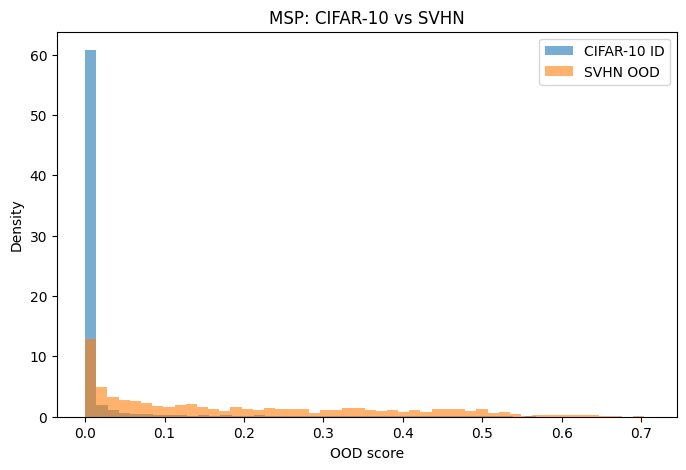

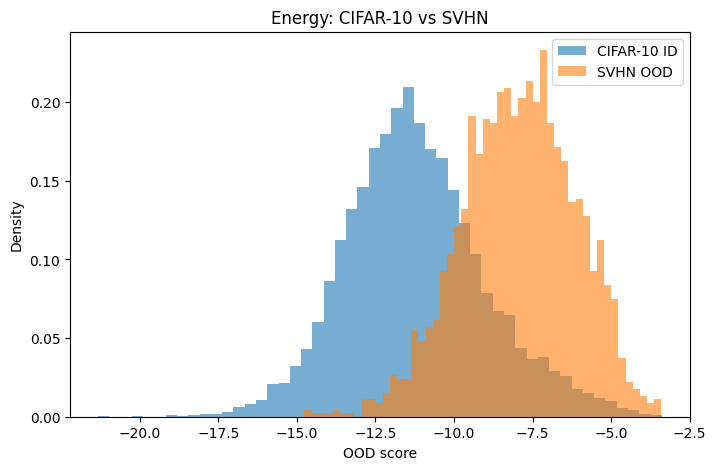

In [26]:
if SKLEARN_AVAILABLE:
    for method in id_scores:
        plt.figure(figsize=(8, 5))

        plt.hist(
            id_scores[method],
            bins=50,
            alpha=0.6,
            density=True,
            label="CIFAR-10 ID",
        )

        plt.hist(
            svhn_scores[method],
            bins=50,
            alpha=0.6,
            density=True,
            label="SVHN OOD",
        )

        plt.xlabel("OOD score")
        plt.ylabel("Density")
        plt.title(f"{method}: CIFAR-10 vs SVHN")
        plt.legend()
        plt.show()

## 18. Save the trained components

In [28]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "ood_head_state_dict": ood_head.state_dict(),
    "weight_energy_state_dict": weight_energy.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),

    "feature_bank": feature_bank.bank.detach().cpu().clone(),
    "feature_bank_counts": feature_bank.counts.detach().cpu().clone(),
    "feature_bank_write_positions":
        feature_bank.write_positions.detach().cpu().clone(),

    "history": history,
    "config": cfg.__dict__,
}

checkpoint_path = "/kaggle/working/data/vos_cifar10_svhn_vos.pt"

torch.save(
    checkpoint,
    checkpoint_path,
)

print("Saved:", checkpoint_path)

RuntimeError: Parent directory /kaggle/working/data does not exist.

## Suggested experiments

After confirming that the notebook runs, try changing one variable at a time:

- `feature_dim`: 2, 16, 32, 64, 128;
- `feature_bank_size`: 100, 200, 500, 1000;
- `candidates_per_class`: 500, 1000, 5000, 10000;
- `outliers_per_class`: 1, 2, 5, 10;
- `vos_weight`: 0.01, 0.05, 0.1, 0.2;
- shared covariance versus class-specific covariance;
- small CNN versus WideResNet;
- frozen two-stage training versus joint training;
- CIFAR-10 versus SVHN, CIFAR-100, LSUN, or Textures.

The closest next step toward the original repository is to replace `SmallCIFARClassifier` with WRN-40-2 and use a 128-dimensional feature representation.